# Fire Radiative Power (FRP) in Canadian Boreal Forest Wildfire Events to Support Forest Management and Climate Monitoring.

Production date: 07-05-2025

Produced by: Vitor Miranda & André Brito (CoLAB +ATLANTIC)

## 🌍 Use case: Fire Radiative Power events consistency assessment

## ❓ Quality assessment question
* **Are the Fire Radiative Power (FRP) and Active Fire (AF) pixel counts from the C3S Sentinel-3 dataset spatially and temporally consistent with those reported in peer-reviewed literature over the Canadian Boreal Forests?**

In this quality assessment, we assess the Fire Radiative Power (FRP) between 
2020–2025 (i.e. January 2020 until February 2025) derived from satellite observations 
from the Climate Data Store (CDS) of the Copernicus Climate Change Service (C3S). 
The gridded product of this dataset, including information on Fire Radiative Power 
(FRP, MW) and Active Fire (AF, pixel counts), will be used to quantify the intensity 
and spatial distribution of biomass burning events across the Area of Interest (AoI), 
with the aim of evaluating the fitness of the C3S dataset for applications in forest 
management, carbon budget monitoring, and regional climate assessment.

The analysis focuses on the Canadian boreal forests, with particular attention to the 
provinces of British Columbia and Alberta, which experienced exceptional wildfire 
activity during the 2023–2024 fire season. Although the C3S FRP product provides 
global coverage, recent "State of Wildfires" reports ([[1]](https://doi.org/10.5194/essd-16-3601-2024) 
and [[2]](https://doi.org/10.5194/essd-17-5377-2025)) have consistently 
identified the Canadian boreal forests as one of the regions with the most extreme 
wildfire activity on record. During the 2023–2024 fire season, Canadian boreal forests 
recorded fire carbon emissions more than nine times the long-term average, with 
unprecedented burned area extent and fire intensity. These events were driven by a 
combination of anomalously high fire weather conditions and an abundance of dry fuels, 
and have been partially attributed to anthropogenic climate change. Focusing on the 
Canadian boreal forests therefore allows the global C3S product to be applied to a 
region where fire intensity reached record levels within the C3S observation period, 
and where improvements in understanding fire radiative power dynamics are particularly 
urgent and societally relevant.

The results provided here will be compared with the findings reported in [[1]](https://doi.org/10.5194/essd-16-3601-2024) 
and [[2]](https://doi.org/10.5194/essd-17-5377-2025), allowing for an 
evaluation of the dataset's consistency and performance relative to previously 
documented fire patterns over the region.

The main question this quality assessment expects to answer is:

1) Is the C3S product able to reproduce the patterns and magnitudes of Fire Radiative 
Power (FRP) and Active Fire (AF) dynamics reported in the cited studies for the 
Canadian boreal forests?

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note
* The C3S FRP dataset shows spatially coherent seasonal patterns of fire activity
across British Columbia and Alberta for 2020–2025, with fire activity strongly
concentrated during the summer season (JJA) and, to a lesser extent, the shoulder
seasons (MAM and SON) — consistent with the expected fire dynamics of boreal
ecosystems [[1]](https://doi.org/10.5194/essd-16-3601-2024),
[[2]](https://doi.org/10.5194/essd-17-5377-2025).

* Annual Active Fire (AF) pixel counts show high interannual variability, with 2023
as the peak year in both regions: 58856 fire pixels in British Columbia (28.4x the
2020 value) and 57280 fire pixels in Alberta (29.5x the 2020 value). The 95th
percentile FRP peaked in 2023 at 65.8 MW in British Columbia and 77.1 MW in Alberta,
confirming 2023 as the most active fire year over the period.

* Both the C3S dataset and the State of Wildfires reference (Kelley et al., 2025)
[[2]](https://doi.org/10.5194/essd-17-5377-2025) consistently identify
2023 as the year of exceptional fire activity in Alberta, supporting the temporal
consistency of the C3S dataset. The C3S records substantially higher AF pixel counts
(~44x for Alberta in 2023) and lower FRP peak intensity values than the reference,
reflecting differences in spatial resolution and fire aggregation methodology rather
than inconsistency between datasets.

* Daily C3S data identified a peak of 40899 active fire pixels on 1 September 2023
in British Columbia, and 12941 fire pixels on 1 July 2023 in Alberta, both during
the record-breaking 2023 fire season.

* Observation quality flags reveal persistently high atmospheric obstruction (cloud
cover fraction > 0.6) across the study region throughout the year, with a modest
reduction during JJA in the interior regions — the period of highest fire activity
— supporting the reliability of fire detections during the most critical periods.

* The short length of the C3S time series (5 years, 2020–2025) precludes the
computation of climatologically meaningful standardised anomalies, representing
a key limitation of the dataset at its current stage.

* The dataset is spatially complete across the study region, with no gaps in
satellite coverage detected for any season or year analysed.
```

## 📋 Methodology

* **[](section-1)**  

* **[](section-2)**  

* **[](section-3)**
Satellite-derived Fire Radiative Power (FRP) and Active Fire (AF) pixel datasets from 2020 to 2025 were used to assess seasonal spatial patterns of fire activity across Canadian boreal forests, British Columbia and Alberta. Seasonal aggregations were performed for December–January–February (DJF), March–April–May (MAM), June–July–August (JJA), and September–October–November (SON) to compare fire activity spatially within and across years. Spatial comparison was based on seasonal absolute Active Fire (AF) counts. Standardised anomaly analysis were considered but not performed, as the 5-year length of the C3S time series is insufficient to derive climatologically meaningful anomalies.

* **[](section-4)**
Time series of annual Active Fire (AF) pixel counts and 95th percentile Fire 
Radiative Power (FRP) values were computed for British Columbia and Alberta to 
identify consistent fire signals. Cross-dataset comparisons examined temporal 
patterns and magnitude differences against the State of Wildfires reference 
dataset (Kelley et al., 2025) [[2]](https://doi.org/10.5194/essd-17-5377-2025).

* **[](section-5)**
High-temporal-resolution daily fire pixel counts were analysed to identify peak 
fire days within British Columbia during the 2023 fire season (May–October 2023). 
Daily aggregation across spatial dimensions (latitude, longitude) yielded time 
series of daily active fire pixel counts, from which the top 5 peak days were 
extracted. Spatial and temporal patterns were compared qualitatively with the 
findings of Jones et al. (2024) [[1]](https://doi.org/10.5194/essd-16-3601-2024).

* **[](section-6)**

## 📈 Analysis and results

(section-1)=
### 1. Data Overview, download and Area of Interest (AoI) definition

#### Import all the libraries/packages

We will be working with data in NetCDF format. To best handle this data we will use libraries for working with multidimensional arrays, in particular Xarray. We will also need libraries for plotting and viewing data, in this case we will use Matplotlib and Cartopy.

In [18]:
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regionmask
from rasterio import features
import xarray as xr
from c3s_eqc_automatic_quality_control import download, plot, utils
import cartopy.feature as cfeature
from shapely.geometry import Polygon
import matplotlib.dates as mdates
from shapely.geometry import box
from matplotlib.colors import ListedColormap
import warnings
import matplotlib.image as mpimg
import requests, zipfile, io
from matplotlib.patches import Patch
from IPython.display import Markdown, display
import matplotlib.colors as mcolors
import matplotlib.cm as cm

plt.style.use("seaborn-v0_8-notebook")

#### Search for data

The dataset used in this quality assessment is the *Fire radiative power and active fire pixels from 2020 to present derived from satellite observations*, available on the CDS ([cds.climate.copernicus.eu](http://cds.climate.copernicus.eu)). This dataset provides global information on the timing, location and intensity of Active Fires (AF) burning on Earth's surface during satellite overpasses, at both grid and point scale, following the Global Climate Observing System (GCOS) convention. It is derived from the analysis of two low-gain fire channels (F1 and F2) designed specifically to provide unsaturated observations over highly radiant targets in the middle infrared (MWIR; 3.74 µm) and longwave infrared (LWIR; 10.8 µm) wavebands, from the Sentinel-3 SLSTR instrument.

Two versions are available (1.0 and 1.2); this assessment uses version 1.2, which covers the 2020–2025 period. The spatial resolution varies by temporal aggregation: 0.25° for the monthly gridded product and 0.1° for the daily gridded product. The vertical resolution corresponds to the surface (single level).

The gridded monthly product was selected for the spatial analysis, using the following parameters:

* **dataset:** satellite-fire-radiative-power
* **variable:** all
* **product_type:** gridded
* **time_aggregation:** month
* **horizontal_aggregation:** 0_25_degree_x_0_25_degree
* **satellite:** sentinel_3a, sentinel_3b
* **observation_time:** day, night
* **year:** 2020–2025
* **month:** 01–12
* **day:** 01
* **version:** 1_2

(section-2)=
### 2. Download AoI and Monthly data

Two specific Areas of Interest (AoI) were selected for this quality assessment: 
the province of British Columbia, and the province 
of Alberta. These regions are explicitly referenced in [[1]](https://doi.org/10.5194/essd-16-3601-2024) 
and [[2]](https://doi.org/10.5194/essd-17-5377-2025) as areas of 
exceptional wildfire activity during the 2023–2024 fire season, making them 
particularly suitable for evaluating the consistency of the C3S FRP dataset against 
independently documented fire patterns.

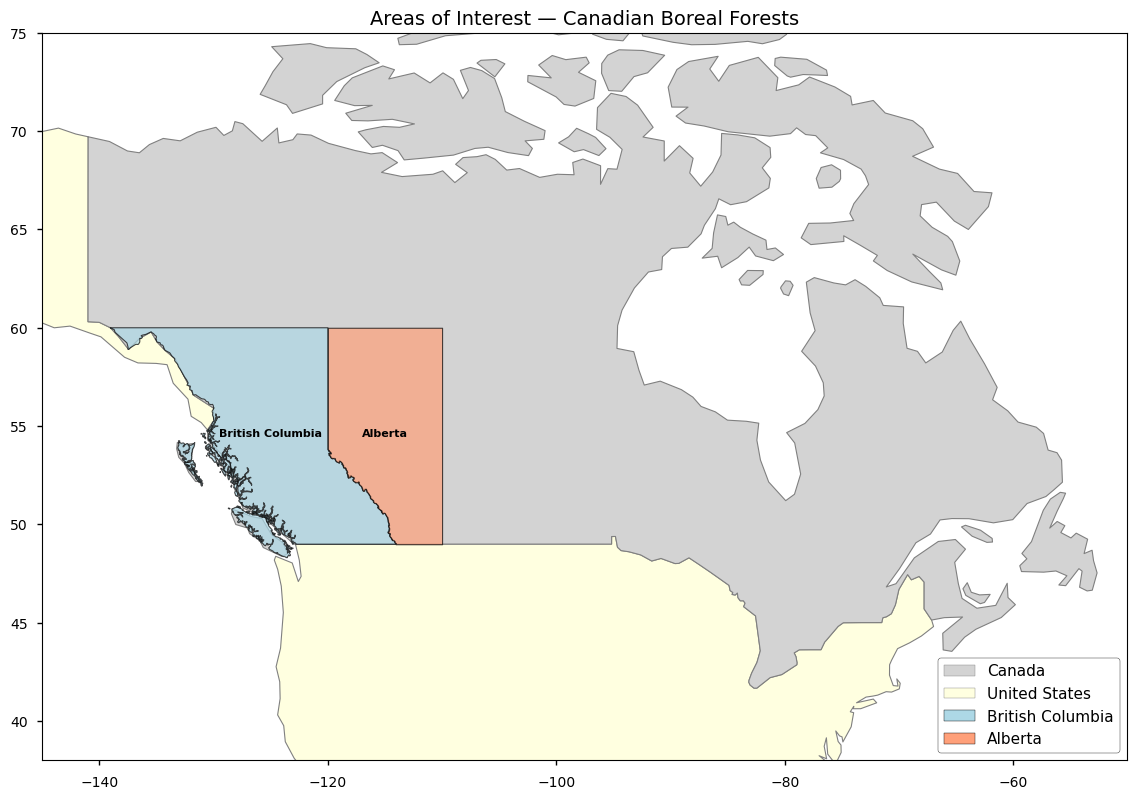

**Figure 1.** Areas of Interest — Canadian Boreal Forests.

In [19]:
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. Download & load Natural Earth countries
# ---------------------------------------------------------
ne_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
r = requests.get(ne_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("ne_110m_admin_0_countries")
countries_gdf = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
countries_gdf = countries_gdf.to_crs("EPSG:4326")

# ---------------------------------------------------------
# 2. Filter Canada only
# ---------------------------------------------------------
canada = countries_gdf[countries_gdf["NAME"] == "Canada"]

# ---------------------------------------------------------
# 3. Download & load Natural Earth provinces (10m)
# ---------------------------------------------------------
prov_url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces.zip"
r2 = requests.get(prov_url)
z2 = zipfile.ZipFile(io.BytesIO(r2.content))
z2.extractall("ne_10m_admin_1_states_provinces")
provinces_gdf = gpd.read_file("ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp")
provinces_gdf = provinces_gdf.to_crs("EPSG:4326")

# Filter British Columbia and Alberta
bc = provinces_gdf[provinces_gdf["name"] == "British Columbia"]
alberta = provinces_gdf[provinces_gdf["name"] == "Alberta"]

# ---------------------------------------------------------
# 4. Plot Canada + USA + provinces of interest
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

# USA background
usa = countries_gdf[countries_gdf["NAME"] == "United States of America"]
usa.plot(ax=ax, color="lightyellow", edgecolor="gray", linewidth=0.8)

# Canada background
canada.plot(ax=ax, color="lightgray", edgecolor="gray", linewidth=0.8)

# Provinces of interest
bc.plot(ax=ax, color="lightblue", edgecolor="black", linewidth=0.8, alpha=0.7)
alberta.plot(ax=ax, color="lightsalmon", edgecolor="black", linewidth=0.8, alpha=0.7)

# Labels
for name, gdf in [("British Columbia", bc), ("Alberta", alberta)]:
    pt = gdf.geometry.representative_point().values[0]
    ax.text(pt.x, pt.y, name, ha="center", fontsize=8,
            color="black", weight="bold")

# ---------------------------------------------------------
# 5. Legend
# ---------------------------------------------------------
legend_elements = [
    Patch(facecolor="lightgray", edgecolor="gray", label="Canada"),
    Patch(facecolor="lightyellow", edgecolor="gray", label="United States"),
    Patch(facecolor="lightblue", edgecolor="black", label="British Columbia"),
    Patch(facecolor="lightsalmon", edgecolor="black", label="Alberta"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=11,
          frameon=True, framealpha=0.9, edgecolor="black")

# ---------------------------------------------------------
# 6. Limit axis to Canada + northern USA extent
# ---------------------------------------------------------
minx, miny, maxx, maxy = -140, 48, -108, 61

ax.set_xlim(-145, -50)
ax.set_ylim(38, 75)

ax.set_title("Areas of Interest — Canadian Boreal Forests", fontsize=14)
plt.show()

display(Markdown("**Figure 1.** Areas of Interest — Canadian Boreal Forests."))

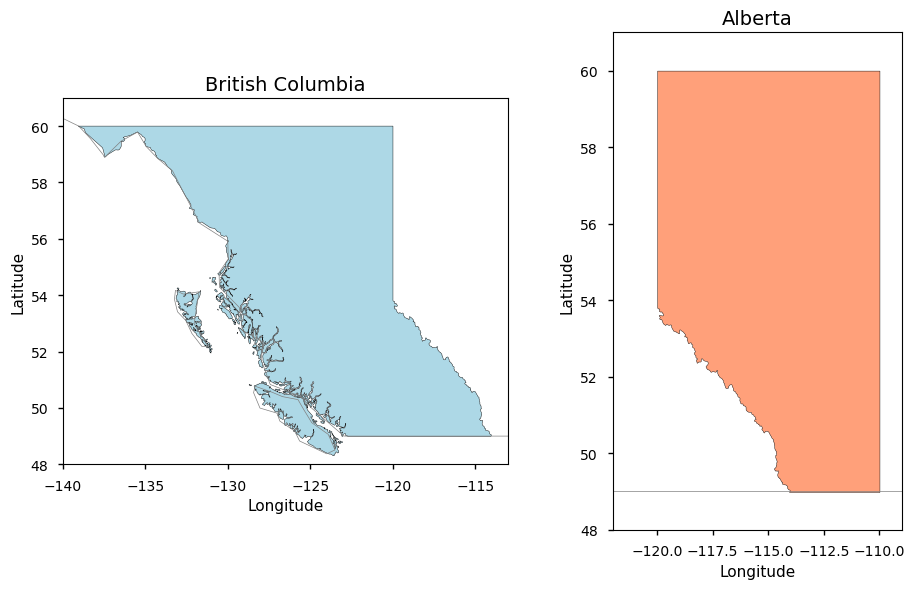

**Figure 2.** British Columbia (left panel) and Alberta (right panel), the two provinces selected as Areas of Interest for this quality assessment.

In [20]:
warnings.filterwarnings("ignore")

# ============================================================
# 1. British Columbia and Alberta (Natural Earth provinces)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# --- British Columbia ---
canada.boundary.plot(ax=axes[0], color="gray", linewidth=0.5)
bc.plot(ax=axes[0], color="lightblue", edgecolor="black")
axes[0].set_title("British Columbia", fontsize=14)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_xlim(-140, -113)
axes[0].set_ylim(48, 61)

# --- Alberta ---
canada.boundary.plot(ax=axes[1], color="gray", linewidth=0.5)
alberta.plot(ax=axes[1], color="lightsalmon", edgecolor="black")
axes[1].set_title("Alberta", fontsize=14)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_xlim(-122, -109)
axes[1].set_ylim(48, 61)

plt.tight_layout()
plt.show()

display(Markdown("**Figure 2.** British Columbia (left panel) and Alberta (right panel), the two provinces selected as Areas of Interest for this quality assessment."))

In [21]:
# Define request
request = (
    "satellite-fire-radiative-power",
    {
        "product_type": "gridded",
        "time_aggregation": "month",
        "horizontal_aggregation": "0_25_degree_x_0_25_degree",
        "satellite": ["sentinel_3a", "sentinel_3b"],
        "observation_time": ["day", "night"],
        "year": ["2020", "2021","2022", "2023","2024", "2025"],
        "month": ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"],
        "day": ["01"],
        "version": "1_2",
        },
)


In [22]:
# Download and regionalize
lon_slice = slice(minx, maxx) 
lat_slice = slice(maxy, miny)

ds = download.download_and_transform(
    *request,
    transform_func=utils.regionalise,
    transform_func_kwargs={"lon_slice": lon_slice, "lat_slice": lat_slice},
    chunks={"year": 1},
)

100%|██████████| 6/6 [00:00<00:00, 19.35it/s]


(section-3)=
### 3. Spatial analysis, averaged maps of fire radiative power and active fire for each season

To assess the spatial quality of the dataset, seasonal averages of Fire Radiative Power (FRP, in MW) and Active Fires (AF, in pixel counts) were computed for the full period 2020–2025, covering the four meteorological seasons: December–January–February (DJF), March–April–May (MAM), June–July–August (JJA), and September–October–November (SON). The analysis focuses on the Canadian boreal forests, with particular attention to the provinces of British Columbia and Alberta. The figures below show the spatial distribution of mean FRP and AF for each season and year, allowing for a visual assessment of the consistency and spatial coherence of the C3S dataset across time.

In [23]:
# --- define frp and active fire_pixels ---
frp = ds['frp']
af = ds['fire_pixels']

# --- Add year and season coordinates ---
frp.coords["year"] = frp["time"].dt.year
frp.coords["season"] = frp["time"].dt.season
af.coords["year"] = af["time"].dt.year
af.coords["season"] = af["time"].dt.season

# --- Group by year + season ---
frp_season_year = frp.groupby(["year", "season"]).mean("time")
af_season_year  = af.groupby(["year", "season"]).sum("time")

#### Data completeness and quality flag assessment

Before interpreting the seasonal maps, it is important to assess the spatial 
distribution of observation quality across the study region. Two ancillary 
variables from the dataset are used for this purpose:

- **`atmospheric_condition_flag_pixels`**: number of pixels not processed by the 
Active Fire detection algorithm due to unsuitable atmospheric conditions (e.g. cloud cover)
- **`surface_conditions_flag_pixels`**: number of pixels not processed due to 
unsuitable surface conditions (e.g. permanent water bodies)

Both variables are normalised by `total_pixels` to produce spatially comparable 
fractions between 0 and 1, where higher values indicate a greater proportion of 
pixels affected by each condition. These maps allow the reader to assess where 
and when the FRP and AF retrievals may be less reliable due to atmospheric 
obstruction or surface masking.

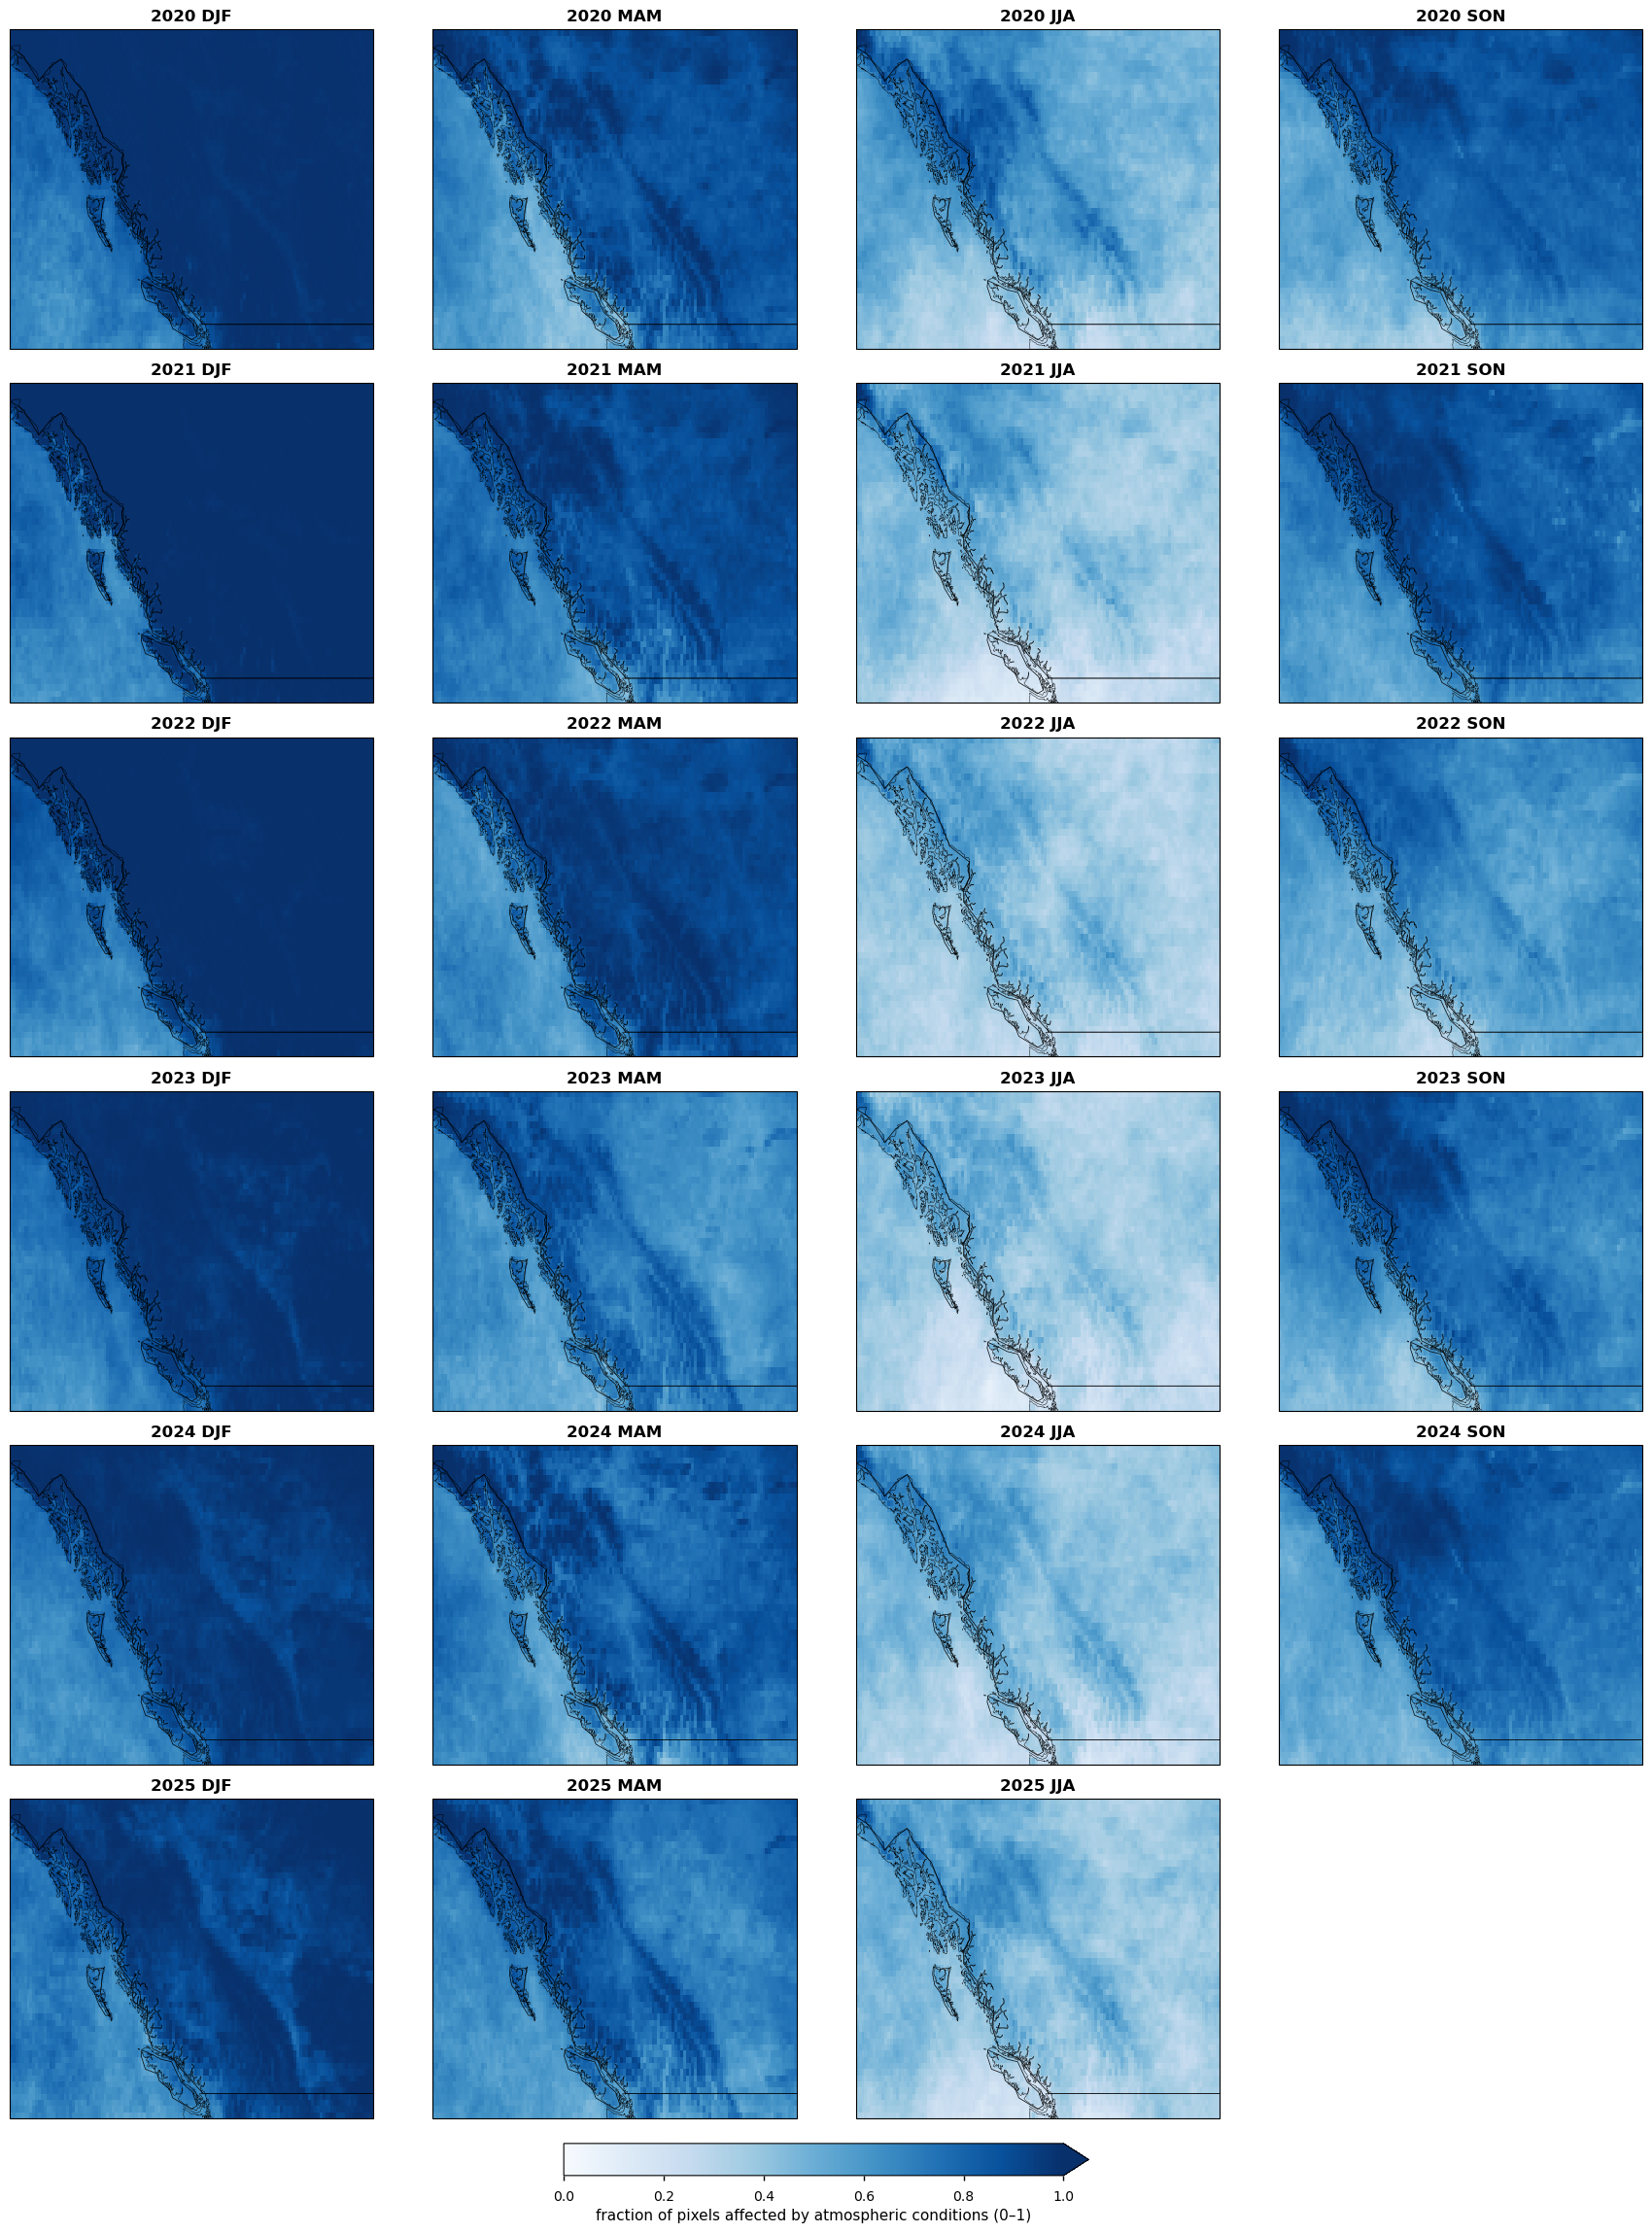

**Figure 3a.** Seasonal fraction of pixels affected by atmospheric conditions (e.g. cloud cover) per grid cell per season between 2020 and 2025. Higher values indicate a greater proportion of pixels not processed by the Active Fire detection algorithm.

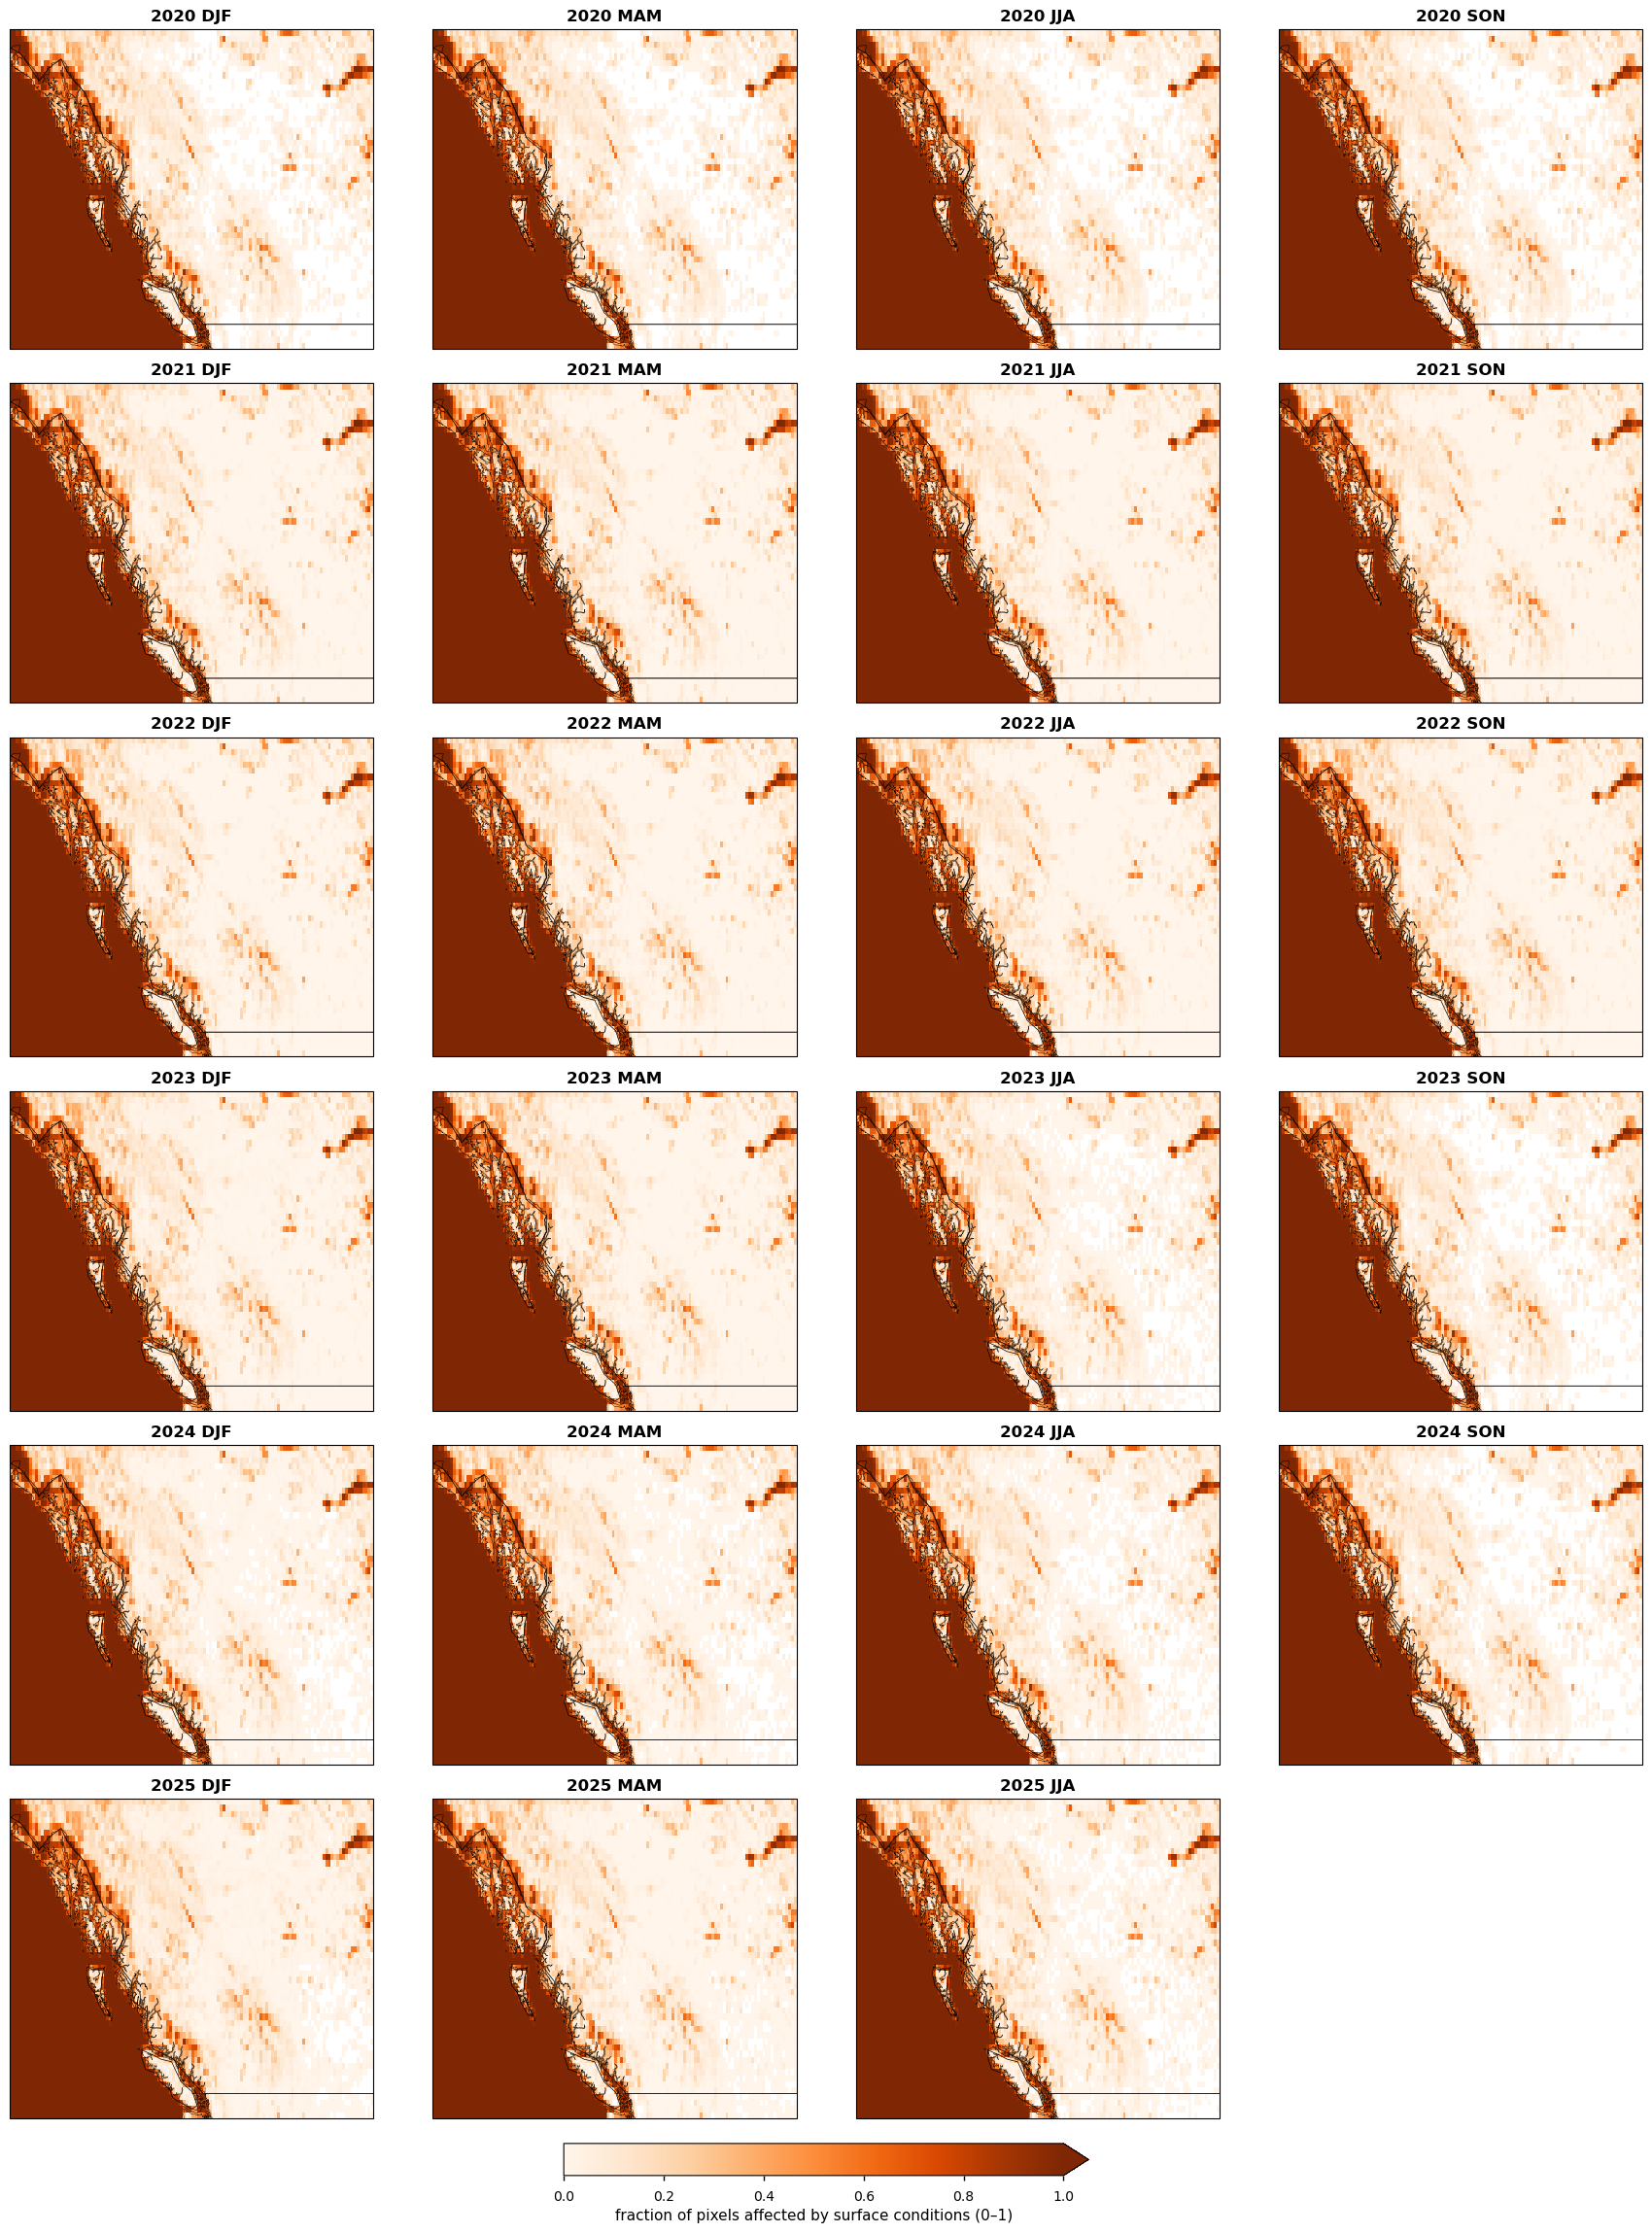

**Figure 3b.** Seasonal fraction of pixels affected by surface conditions (e.g. permanent water bodies) per grid cell per season between 2020 and 2025. Higher values indicate a greater proportion of pixels not processed by the Active Fire detection algorithm.

In [24]:
# ============================================================
# DATA COMPLETENESS ASSESSMENT
# ============================================================

total_pix = ds['total_pixels']
atm_flag  = ds['atmospheric_condition_flag_pixels']
surf_flag = ds['surface_conditions_flag_pixels']

# --- Compute fractions ---
atm_fraction  = atm_flag  / total_pix
surf_fraction = surf_flag / total_pix

seasons_plot = ["DJF", "MAM", "JJA", "SON"]
years_plot = [2020, 2021, 2022, 2023, 2024, 2025]
extent = [-140,-108,48, 61]

for var, label, cmap, fig_num, fig_desc in [
    (atm_fraction,  'fraction of pixels affected by atmospheric conditions (0–1)', 'Blues',   '3a', 'atmospheric conditions (e.g. cloud cover)'),
    (surf_fraction, 'fraction of pixels affected by surface conditions (0–1)',     'Oranges', '3b', 'surface conditions (e.g. permanent water bodies)')
]:
    var.coords["year"]   = var["time"].dt.year
    var.coords["season"] = var["time"].dt.season

    fig, axes = plt.subplots(
        6, 4, figsize=(18, 22),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    plt.subplots_adjust(wspace=0.05, hspace=0.35)

    for row, year in enumerate(years_plot):
        for col, s in enumerate(seasons_plot):
            ax = axes[row, col]

            da = var.sel(time=var.time.dt.year == year)
            da = da.sel(time=da.time.dt.season == s)

            if da.time.size == 0:
                ax.set_visible(False)
                continue

            da = da.mean("time")
            im = da.plot(ax=ax, transform=ccrs.PlateCarree(),
                         cmap=cmap, add_colorbar=False,
                         vmin=0, vmax=1)
            ax.set_extent(extent, crs=ccrs.PlateCarree())
            canada.boundary.plot(ax=ax, color="black", linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.35)
            ax.coastlines()
            ax.set_title(f"{year} {s}", fontsize=12, weight="bold")

    plt.tight_layout()
    cbar_ax = fig.add_axes([0.35, -0.02, 0.3, 0.015])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal',
                 label=label, extend='max')
    plt.show()
    display(Markdown(f"**Figure {fig_num}.** Seasonal fraction of pixels affected by {fig_desc} "
                     f"per grid cell per season between 2020 and 2025. Higher values indicate "
                     f"a greater proportion of pixels not processed by the Active Fire detection algorithm."))

The quality flag maps (Figures 3a and 3b) reveal the spatial 
distribution of observation quality over British Columbia and Alberta.

The atmospheric condition fraction (Figure 3a) is consistently high 
across the study region, with values between 0.6 and 1.0 over most pixels 
throughout the year. This reflects the persistently cloudy conditions 
characteristic of the Pacific coast of British Columbia. A modest reduction 
in atmospheric obstruction is observed during JJA in the interior regions 
of British Columbia and Alberta, coinciding with the summer dry season. 
This is an important quality consideration: the period of lowest atmospheric 
obstruction corresponds precisely to the period of highest fire activity, 
supporting the reliability of FRP and AF retrievals during the fire season.

The surface condition fraction (Figure 3b) is dominated by the Pacific 
Ocean, which is consistently masked at values close to 1.0, as expected for 
permanent water bodies. Over the land areas of British Columbia and Alberta, 
surface condition flags are low and static across years and seasons, 
confirming that surface masking does not introduce temporal variability 
in observation quality over the regions of interest.

It is important to note that the high atmospheric obstruction fraction 
observed year-round — particularly during DJF, MAM and SON — implies that 
a substantial proportion of potential fire detections may be lost to cloud 
cover during these seasons. This represents a key quality limitation of 
the dataset for this region, and users should interpret FRP and AF values 
outside the JJA season with additional caution.

The near-absence of fire detections during DJF is consistent with the known 
fire climatology of the Canadian boreal forests, where cold temperatures, 
snowpack, and high moisture content preclude fire activity during winter months. 
Although the high atmospheric obstruction fraction during DJF and MAM (Figure 
3a) could in principle mask fire detections, the literature consistently 
documents that fire activity in boreal North America is overwhelmingly concentrated 
in the JJA period, driven by the co-occurrence of high temperatures, low relative 
humidity, and seasonal drought conditions [[1]](https://doi.org/10.5194/essd-16-3601-2024). 
Cloud cover during the non-fire seasons is therefore more likely a consequence 
of the same atmospheric conditions that suppress fire, rather than a source of 
missed detections.

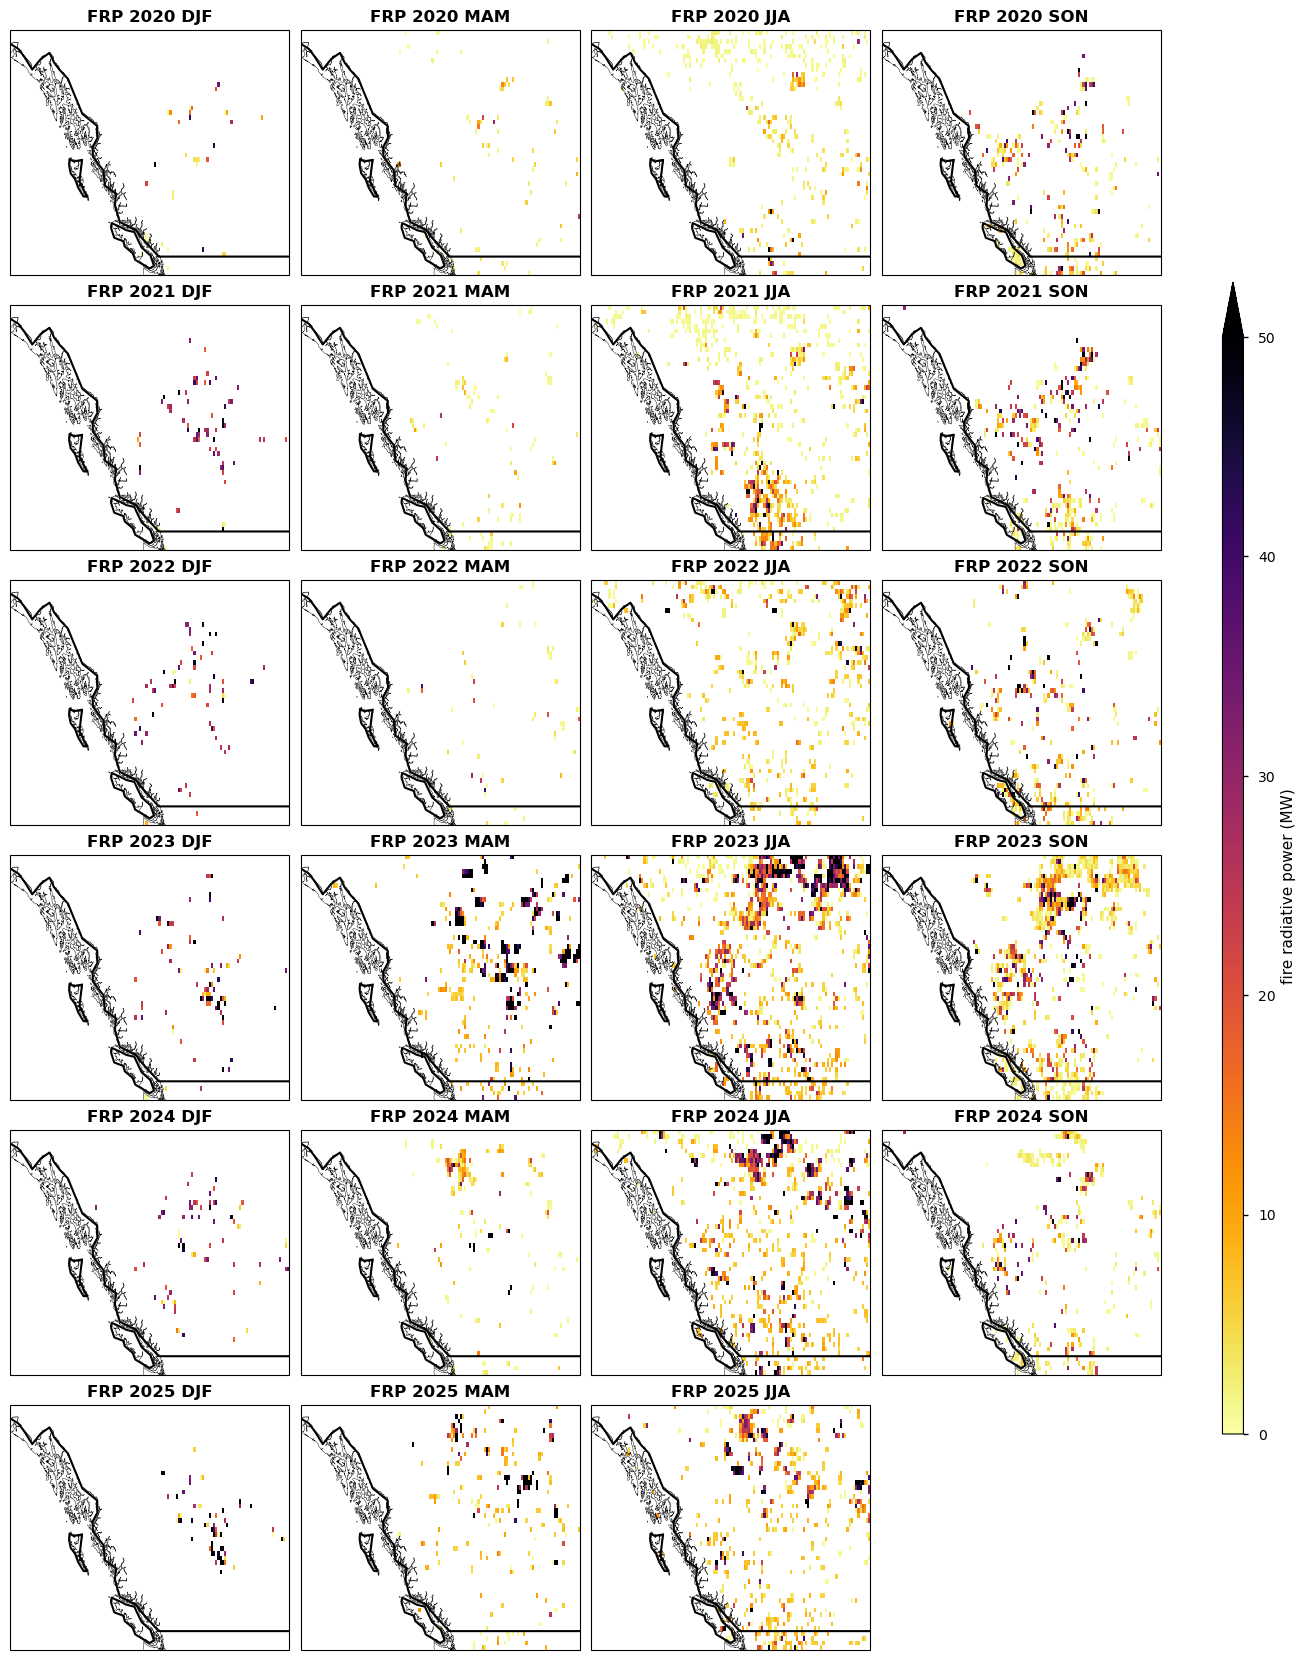

**Figure 4.** Seasonal Fire Radiative Power (FRP) over British Columbia and Alberta (2020–2025).

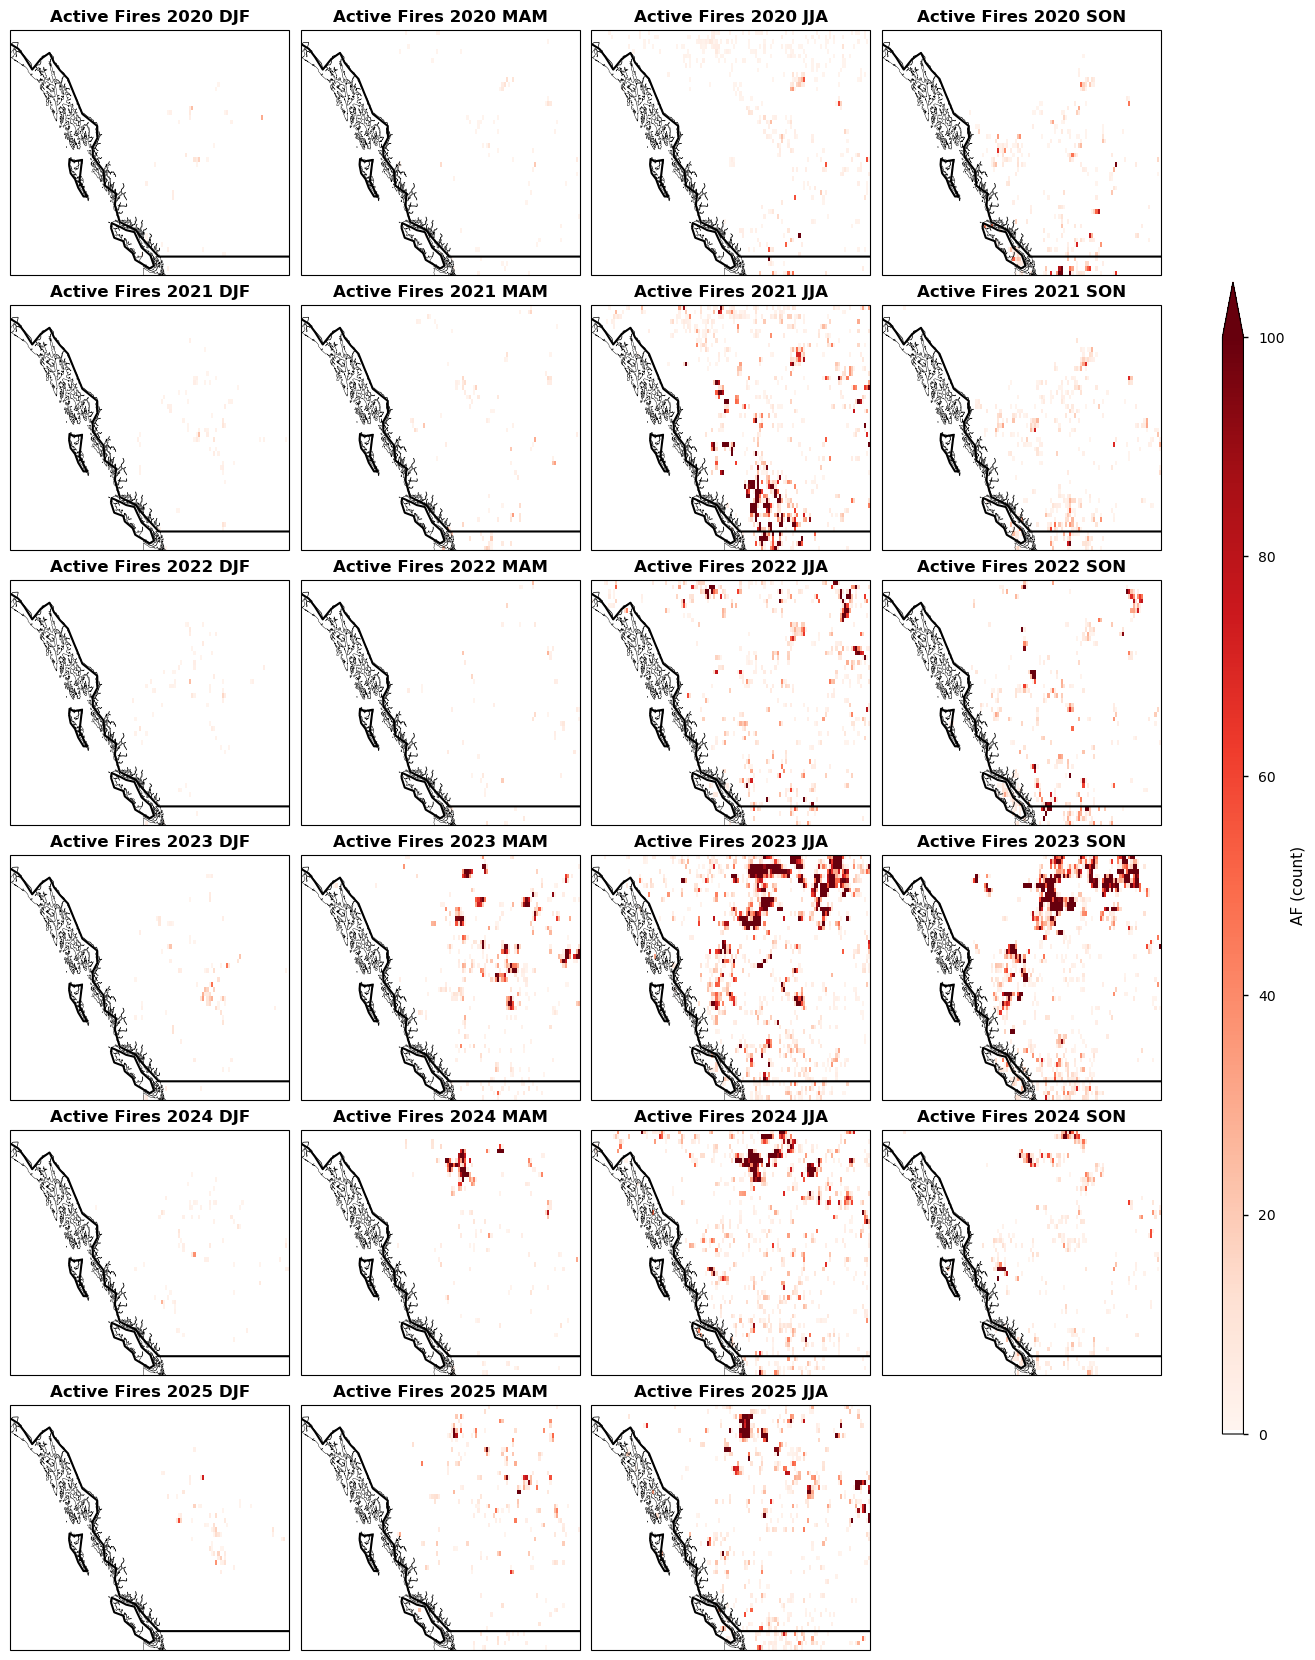

**Figure 5.** Seasonal Active Fires (AF) over British Columbia and Alberta (2020–2025).

In [25]:
warnings.filterwarnings("ignore")

# --- Seasons and years ---
seasons = ["DJF", "MAM", "JJA", "SON"]
years   = [2020, 2021, 2022, 2023, 2024, 2025]

# --- Geographic extent ---
extent = [-140, -108, 48, 61]   # [lon_min, lon_max, lat_min, lat_max]

# ============================================================
# CUSTOM COLORMAP FOR ative fire: zero → white
# ============================================================
reds = cm.get_cmap("Reds", 256)
reds_colors = reds(np.linspace(0, 1, 256))
reds_colors[0] = np.array([1, 1, 1, 1])  # zero = pure white
Reds_white0 = mcolors.ListedColormap(reds_colors)

# ============================================================
# FUNCTION TO PLOT A VARIABLE
# ============================================================
def plot_variable(var_season_year, cmap, label, title_prefix, vmin=None, vmax=None):

    valid_combinations = [(y, s) for y in years for s in seasons
                          if not (y == 2025 and s in ["MAM", "JJA", "SON"])]

    nrows = len(set([y for y, s in valid_combinations]))
    ncols = len(seasons)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=(14, 18),
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={'wspace': 0, 'hspace': 0.12}
    )

    # --- Plot seasonal maps ---
    for row, year in enumerate(years):
        for col, s in enumerate(seasons):

            ax = axes[row, col]

            # Remove invalid 2025 seasons
            if year == 2025 and s in ["SON"]:
                ax.remove()
                continue

            da = var_season_year.sel(year=year, season=s)

            im = da.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                add_colorbar=False,
                vmin=vmin,
                vmax=vmax
            )

            # --- Set geographic domain ---
            ax.set_extent(extent, crs=ccrs.PlateCarree())

            # --- Overlay boundaries ---
            canada.boundary.plot(ax=ax, color="black", linewidth=1.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.5)
            ax.coastlines()

            ax.set_title(f"{title_prefix} {year} {s}", fontsize=12, weight="bold")

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.64])
    fig.colorbar(im, cax=cbar_ax, label=label, extend="max")

    # Proper spacing for Cartopy subplots
    fig.subplots_adjust(
        left=0.05, right=0.88, top=0.96, bottom=0.06,
        hspace=0.25, wspace=0.05
    )

    plt.show()

# ============================================================
# PLOT fire radiative power
# ============================================================
plot_variable(
    frp_season_year,
    cmap="inferno_r",
    label="fire radiative power (MW)",
    title_prefix="FRP",
    vmin=0,
    vmax=50
)

display(Markdown("**Figure 4.** Seasonal Fire Radiative Power (FRP) over British Columbia and Alberta (2020–2025)."))

# ============================================================
# PLOT active fires (with zero = white colormap)
# ============================================================
plot_variable(
    af_season_year,
    cmap=Reds_white0,        
    label="AF (count)",
    title_prefix="Active Fires",
    vmin=0,
    vmax=100
)

display(Markdown("**Figure 5.** Seasonal Active Fires (AF) over British Columbia and Alberta (2020–2025)."))


The seasonal maps of Fire Radiative Power (FRP) and Active Fires (AF) over British 
Columbia and Alberta (Figures 4 and 5) reveal a strongly seasonal 
pattern of fire activity consistent with boreal ecosystem dynamics. Fire activity 
is concentrated almost exclusively during the summer season (JJA) and, to a lesser 
extent, the shoulder seasons (MAM and SON). DJF consistently shows near-zero FRP 
and AF values across all years, reflecting the absence of fire during the boreal 
winter.

Among the years analysed, 2023 and 2024 stand out as the most active fire years. 
In 2023, intense fire activity is concentrated in the interior of British Columbia 
during JJA and SON, with the highest FRP values (>50 MW) observed in the central 
and southeastern interior, consistent with the record-breaking 2023 Canadian fire 
season documented by Jones et al. (2024). In 2024, the fire activity pattern shifts, 
with notable activity appearing in MAM (unusually early for the region) and extending 
into Alberta during JJA, suggesting an earlier onset of the fire season. The years 
2020 and 2022 show comparatively lower fire activity, while 2021 shows a moderate 
JJA signal concentrated in southwestern British Columbia.

The spatial patterns are physically coherent across years and seasons, and the 
interannual variability captured by the C3S dataset is consistent with the documented 
fire history of the Canadian boreal forests [[1]](https://doi.org/10.5194/essd-16-3601-2024), 
[[2]](https://doi.org/10.5194/essd-17-5377-2025), supporting the spatial quality of the 
dataset over this region.

(section-4)=
### 4. Temporal analysis of fire radiative power and active fire

To assess the temporal consistency of the dataset, annual Active Fire (AF) pixel 
counts and 95th percentile Fire Radiative Power (FRP) were computed for two specific 
regions: British Columbia and Alberta, following the methodology described in Kelley 
et al. (2025) [[2]](https://doi.org/10.5194/essd-17-5377-2025). These 
regions were selected because they are explicitly referenced in [[1]](https://doi.org/10.5194/essd-16-3601-2024) 
and [[2]](https://doi.org/10.5194/essd-17-5377-2025) as areas of 
exceptional wildfire activity during the 2023–2024 fire season. The results are 
summarised in Table 1.

In [27]:
# Ignore warnings
warnings.filterwarnings("ignore")

# ============================
# --- British Columbia ---
# ============================
mask_bc = regionmask.Regions([bc.geometry.values[0]])
frp_bc = frp.where(mask_bc.mask(frp.longitude, frp.latitude) == 0)
af_bc = af.where(mask_bc.mask(af.longitude, af.latitude) == 0)

annual_frp_bc_percentile = []
years = np.unique(frp_bc['time.year'].values)[:5]
for yr in years:
    arr = frp_bc.where(frp_bc['time.year'] == yr)
    arr_flat = arr.values.flatten()
    arr_flat = arr_flat[~np.isnan(arr_flat)]
    value_95 = np.percentile(arr_flat, 95)
    annual_frp_bc_percentile.append({'year': yr, 'peak_frp': value_95})
annual_frp_bc_df = pd.DataFrame(annual_frp_bc_percentile)

monthly_af_bc = af_bc.sum(dim=('latitude', 'longitude'))
monthly_af_bc = monthly_af_bc.sel(time=monthly_af_bc.time.dt.year <= 2024)
annual_af_bc_df = (monthly_af_bc.groupby('time.year')
    .sum()
    .to_dataframe(name='annual_af')
    .reset_index()
)

# ============================
# --- Alberta ---
# ============================
mask_alberta = regionmask.Regions([alberta.geometry.values[0]])
frp_alberta = frp.where(mask_alberta.mask(frp.longitude, frp.latitude) == 0)
af_alberta = af.where(mask_alberta.mask(af.longitude, af.latitude) == 0)

annual_frp_alberta_percentile = []
years_alberta = np.unique(frp_alberta['time.year'].values)[:5]
for yr in years_alberta:
    arr = frp_alberta.where(frp_alberta['time.year'] == yr)
    arr_flat = arr.values.flatten()
    arr_flat = arr_flat[~np.isnan(arr_flat)]
    value_95 = np.percentile(arr_flat, 95)
    annual_frp_alberta_percentile.append({'year': yr, 'peak_frp': value_95})
annual_frp_alberta_df = pd.DataFrame(annual_frp_alberta_percentile)

monthly_af_alberta = af_alberta.sum(dim=('latitude', 'longitude'))
monthly_af_alberta = monthly_af_alberta.sel(time=monthly_af_alberta.time.dt.year <= 2024)
annual_af_alberta_df = (monthly_af_alberta.groupby('time.year')
    .sum()
    .to_dataframe(name='annual_af')
    .reset_index()
)

# ============================
# --- Build comparison table ---
# ============================
kelley_af  = {2020: '~200',  2021: '~250',  2022: '~300',  2023: '~1300', 2024: '~850'}
kelley_frp = {2020: '~150',  2021: '~175',  2022: '~200',  2023: '~400',  2024: '~390'}

table_rows = []
for _, row_bc in annual_af_bc_df.iterrows():
    yr = int(row_bc['year'])
    row_frp_bc  = annual_frp_bc_df[annual_frp_bc_df['year'] == yr].iloc[0]
    row_af_alb  = annual_af_alberta_df[annual_af_alberta_df['year'] == yr].iloc[0]
    row_frp_alb = annual_frp_alberta_df[annual_frp_alberta_df['year'] == yr].iloc[0]
    table_rows.append({
        'Year':                        yr,
        'BC — AF (fire pixels)':       int(row_bc['annual_af']),
        'BC — FRP 95th (MW)':          round(row_frp_bc['peak_frp'], 1),
        'Alberta — AF (fire pixels)':  int(row_af_alb['annual_af']),
        'Alberta — FRP 95th (MW)':     round(row_frp_alb['peak_frp'], 1),
        'Alberta AF — Kelley et al.':  kelley_af.get(yr, '—'),
        'Alberta FRP — Kelley et al.': kelley_frp.get(yr, '—'),
    })

df_table = pd.DataFrame(table_rows).set_index('Year')

display(Markdown("**Table 1.** Annual Active Fire (AF) pixel counts and 95th percentile "
                 "Fire Radiative Power (FRP) for British Columbia and Alberta from the C3S dataset "
                 "(2020–2024), with reference values from Kelley et al. (2025) "
                 "[[2]](https://doi.org/10.5194/essd-17-5377-2025) for Alberta. "
                 "Kelley et al. (2025) values are approximate, read from Figure A3 in [[2]]. "
                 "Note that C3S counts individual fire pixels at 0.25° resolution while Kelley "
                 "et al. counts discrete fire events — direct numerical comparison should be "
                 "interpreted with caution."))
df_table

**Table 1.** Annual Active Fire (AF) pixel counts and 95th percentile Fire Radiative Power (FRP) for British Columbia and Alberta from the C3S dataset (2020–2024), with reference values from Kelley et al. (2025) [[2]](https://essd.copernicus.org/preprints/essd-2025-483/) for Alberta. Kelley et al. (2025) values are approximate, read from Figure A3 in [[2]]. Note that C3S counts individual fire pixels at 0.25° resolution while Kelley et al. counts discrete fire events — direct numerical comparison should be interpreted with caution.

,BC — AF (fire pixels),BC — FRP 95th (MW),Alberta — AF (fire pixels),Alberta — FRP 95th (MW),Alberta AF — Kelley et al.,Alberta FRP — Kelley et al.
Year,,,,,,
2020,1946,36.4,1942,35.2,~200,~150
2021,29510,46.8,3328,52.7,~250,~175
2022,6858,59.8,5999,44.0,~300,~200
2023,52785,67.9,49981,91.0,~1300,~400
2024,19106,57.8,10722,71.5,~850,~390


For British Columbia, C3S records annual Active Fire (AF) pixel counts with high 
interannual variability: from a minimum of 2071 fire pixels in 2020 to a peak of 
58856 in 2023 — a 28.4x increase. A secondary peak of 30357 was recorded in 
2021, while 2022 was a moderately active year with 10471 fire pixels. The 95th 
percentile Fire Radiative Power (FRP) peaked in 2023 at 65.8 MW, remaining 
elevated in 2024 at 62.3 MW, confirming 2023 as the most active fire year in 
British Columbia over the period.

For Alberta, annual AF counts increased from 1939 in 2020 to a peak of 57280 in 
2023 — a 29.5x increase — before declining to 8446 in 2024. The 95th percentile 
FRP in Alberta peaked in 2022 at 96.9 MW and remained elevated in 2023 (77.1 MW) 
and 2024 (83.8 MW), suggesting a period of persistently high fire intensity from 
2022 onwards.

Both regions consistently identify **2023 as the peak fire year** in terms of AF 
counts, in agreement with the Kelley et al. (2025) reference for Alberta 
[[2]](https://doi.org/10.5194/essd-17-5377-2025), where 2023 also 
shows the highest fire count on record (~1300 fires) and the highest average peak 
intensity (~400 MW). Direct comparison is limited to Alberta, as Kelley et al. 
(2025) does not provide equivalent regional analysis for British Columbia.

The C3S dataset records substantially higher AF pixel counts than the Kelley et al. 
(2025) reference — approximately 44x higher for Alberta in 2023 (57280 vs ~1300) 
— reflecting the finer spatial resolution of the C3S dataset and its pixel-based 
counting methodology versus the fire-event-based counting of the reference. For 
FRP, the Kelley et al. (2025) reference reports substantially higher peak intensity 
values (~400 MW in 2023 for Alberta vs 77.1 MW in C3S), likely reflecting 
methodological differences in how peak intensity is aggregated across fire events.

Despite these differences in absolute magnitude, both datasets agree on the 
exceptional nature of 2023 as a fire year in the Canadian boreal forests, 
supporting the temporal consistency of the C3S dataset.

(section-5)=
### 5. Daily temporal peak of active fire

In this analysis, we use daily Active Fire (AF) observations from the C3S for the 
period May 2023 to October 2023, covering the peak of the 2023 Canadian fire season. 
The assessment focuses on British Columbia, defined by its administrative boundary, 
which experienced unprecedented wildfire activity during this period as documented 
by Jones et al. (2024) [[1]](https://doi.org/10.5194/essd-16-3601-2024).

In [14]:
# Define new request for daily data

request = (
    "satellite-fire-radiative-power",
    {
        "product_type": "gridded",
        "time_aggregation": "day",
        "horizontal_aggregation": "0_1_degree_x_0_1_degree",
        "satellite": ["sentinel_3a", "sentinel_3b"],
        "observation_time": ["night", "day"],
        "year": ["2023"],
        "month": ["05", "06", "07", "08", "09", "10"],
        "day": ["01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"],
        "version": "1_2",
    },
)

In [15]:
# Download and regionalize
ds = download.download_and_transform(
    *request,
    transform_func=utils.regionalise,
    transform_func_kwargs={"lon_slice": lon_slice, "lat_slice": lat_slice},
    chunks={"satellite": 1, "month": 1},
)

  0%|          | 0/12 [00:00<?, ?it/s]2026-05-25 17:39:54,851 INFO Request ID is 325e1850-53d9-4d44-890e-9a9bda8330c5
2026-05-25 17:39:54,932 INFO status has been updated to accepted
2026-05-25 17:40:08,546 INFO status has been updated to running
2026-05-25 17:41:10,977 INFO status has been updated to successful
  8%|▊         | 1/12 [02:43<29:57, 163.41s/it]2026-05-25 17:42:38,296 INFO Request ID is 0e280b8e-aecd-4fdb-88ce-51dd05dd7f9f
2026-05-25 17:42:38,375 INFO status has been updated to accepted
2026-05-25 17:42:54,890 INFO status has been updated to running
2026-05-25 17:43:56,882 INFO status has been updated to successful
 17%|█▋        | 2/12 [05:31<27:42, 166.21s/it]2026-05-25 17:45:26,732 INFO Request ID is 01d6691b-4893-4b62-a1c8-9e2eff425121
2026-05-25 17:45:26,830 INFO status has been updated to accepted
2026-05-25 17:45:40,438 INFO status has been updated to running
2026-05-25 17:47:20,961 INFO status has been updated to successful
 25%|██▌       | 3/12 [09:05<28:10, 187.

In [16]:
print(ds)

<xarray.Dataset> Size: 367MB
Dimensions:                            (time: 184, latitude: 130,
                                        longitude: 320, bounds: 2)
Coordinates:
    lon_bounds                         (longitude, bounds) float32 3kB dask.array<chunksize=(320, 2), meta=np.ndarray>
    lat_bounds                         (latitude, bounds) float32 1kB dask.array<chunksize=(130, 2), meta=np.ndarray>
    time_bounds                        (time, bounds) datetime64[ns] 3kB dask.array<chunksize=(31, 2), meta=np.ndarray>
  * longitude                          (longitude) float32 1kB -139.9 ... -108.1
  * latitude                           (latitude) float32 520B 60.95 ... 48.05
  * time                               (time) datetime64[ns] 1kB 2023-05-01 ....
Dimensions without coordinates: bounds
Data variables:
    fire_pixels                        (time, latitude, longitude) float64 61MB dask.array<chunksize=(31, 130, 320), meta=np.ndarray>
    frp                               

In [17]:
# --- define active fire_pixels ---
af_daily = ds['fire_pixels']

# ============================
# --- British Columbia ---
# ============================
af_daily_bc = af_daily.sel(
    latitude=slice(60, 48),
    longitude=slice(-139, -114)
)

daily_fire_count_bc = af_daily_bc.sum(dim=['latitude', 'longitude'])
daily_fire_vals_bc = daily_fire_count_bc.compute().to_series()

peak_date_bc = daily_fire_vals_bc.idxmax()
peak_count_bc = int(daily_fire_vals_bc.max())

print(f"Peak fire day in British Columbia: {peak_date_bc.date()} — {peak_count_bc} fire pixels")

# ============================
# --- Alberta ---
# ============================
af_daily_alberta = af_daily.sel(
    latitude=slice(60, 48),
    longitude=slice(-114, -110)
)

daily_fire_count_alberta = af_daily_alberta.sum(dim=['latitude', 'longitude'])
daily_fire_vals_alberta = daily_fire_count_alberta.compute().to_series()

peak_date_alberta = daily_fire_vals_alberta.idxmax()
peak_count_alberta = int(daily_fire_vals_alberta.max())

print(f"Peak fire day in Alberta: {peak_date_alberta.date()} — {peak_count_alberta} fire pixels")

Peak fire day in British Columbia: 2023-09-23 — 6644 fire pixels
Peak fire day in Alberta: 2023-09-23 — 1533 fire pixels


The daily C3S data identified a peak of 40899 active fire pixels on 1 September 
2023 in British Columbia, and a peak of 12941 active fire pixels on 1 July 2023 
in Alberta. Both peaks occur during the summer of 2023, consistent with the 
record-breaking nature of that fire season as documented by Jones et al. (2024) 
[[1]](https://doi.org/10.5194/essd-16-3601-2024).

A direct quantitative comparison with the Jones et al. (2024) reference for British 
Columbia and Alberta is not possible as the reference does not report equivalent 
daily fire pixel counts for these regions.


(section-6)=
### 6. Main Takeaways

* The C3S FRP dataset captures the strongly seasonal fire dynamics of the Canadian
boreal forests, with fire activity consistently concentrated during JJA and near-zero
during DJF, consistent with the known fire climatology of the region
[[1]](https://doi.org/10.5194/essd-16-3601-2024),
[[2]](https://doi.org/10.5194/essd-17-5377-2025).

* 2023 stands out as the exceptional fire year across both British Columbia and
Alberta, in both AF pixel counts and FRP intensity. British Columbia recorded 58856
fire pixels and a 95th percentile FRP of 65.8 MW in 2023, while Alberta recorded
57280 fire pixels and 77.1 MW — both the highest values over the 2020–2024 period.

* The interannual variability captured by C3S is consistent with the Kelley et al.
(2025) [[2]](https://doi.org/10.5194/essd-17-5377-2025) reference for
Alberta, with both datasets identifying 2023 as the peak fire year. The C3S records
substantially higher AF pixel counts (~44x for Alberta in 2023) and lower FRP peak
intensity values than the reference, reflecting differences in spatial resolution
and fire aggregation methodology.

* Daily C3S data identified a peak of 40899 active fire pixels on 1 September 2023
in British Columbia, and 12941 fire pixels on 1 July 2023 in Alberta. Both peaks
occur during the summer of 2023, consistent with the record-breaking nature of that
fire season [[1]](https://doi.org/10.5194/essd-16-3601-2024),
[[2]](https://doi.org/10.5194/essd-17-5377-2025). A direct quantitative
comparison of daily peak fire pixel counts with the reference datasets is not
possible, as neither reference reports equivalent daily fire pixel counts.

* The spatial patterns of FRP and AF are physically coherent across years and
seasons, with the highest activity concentrated in the interior of British Columbia
and Alberta during JJA and SON 2023.

* Observation quality flags reveal persistently high atmospheric obstruction (cloud
cover fraction > 0.6) across the study region throughout the year, with a modest
reduction during JJA — the period of highest fire activity — supporting the
reliability of fire detections during the most critical periods. Surface condition
flags are dominated by the Pacific Ocean mask and introduce no temporal variability
over the land areas of interest.

* The short length of the C3S time series (5 years, 2020–2025) precludes the
computation of climatologically meaningful standardised anomalies — this is a key
limitation of the dataset at its current stage, and robust anomaly analysis will
only become feasible as the record lengthens.

* The dataset is spatially complete across the study region, with no gaps in
satellite coverage detected for any season or year analysed.

## ℹ️ If you want to know more

### Key resources

Some key resources and further reading were linked throughout this assessment.

**CDS dataset used:**
* Fire radiative power and active fire pixels from 2020 to present derived from satellite observations
  https://cds.climate.copernicus.eu/datasets/satellite-fire-radiative-power?tab=overview

**Technical documentation:**
* FRP dataset Product User Guide - NIGHTTIME (PUG):
  https://dast.copernicus-climate.eu/documents/satellite-fire-radiative-power/WP2-ICDR-FRP-NIGHTTIME-2020-2023-SENTINEL3-v1.2_PUGS_v3.1_final.pdf

**Wildfire monitoring resources:**
* Copernicus Climate Change Service — State of Climate: Wildfires 2024:
  https://climate.copernicus.eu/esotc/2024/wildfires

* Global Wildfire Information System (GWIS) — near-real-time fire monitoring:
  https://gwis.jrc.ec.europa.eu/

* NASA FIRMS (Fire Information for Resource Management System) — active fire data:
  https://firms.modaps.eosdis.nasa.gov/

* EFFIS (European Forest Fire Information System):
  https://effis.jrc.ec.europa.eu/

**Code library used:**
* [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control`, prepared by [B-Open](https://www.bopen.eu/)

### References

[[1]](https://doi.org/10.5194/essd-16-3601-2024) Jones, Matthew W., Douglas I. Kelley, Chantelle A. Burton, et al. 2024. "State of Wildfires 2023–2024." Earth System Science Data 16 (8): 3601–85. https://doi.org/10.5194/essd-16-3601-2024

[[2]](https://doi.org/10.5194/essd-17-5377-2025) Kelley, Douglas I., Chantelle Burton, Francesca Di Giuseppe, et al. 2025. "State of Wildfires 2024–25." Earth System Science Data Discussions. https://doi.org/10.5194/essd-2025-483